RRC filter length = 65
Filter span       = 8 symbols
Samples/symbol    = 8

First 20 bits:
[0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0]

First 20 BPSK symbols:
[-1  1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1  1 -1  1  1  1 -1]

----------------------------------------
DELAY VALIDATION
----------------------------------------
TX filter delay      = 32 samples
RX matched delay     = 32 samples
Total cascade delay  = 64 samples
----------------------------------------
Number of detected symbols = 4000
BER at SNR = 10 dB = 0.0

First 15 symbol decisions:
----------------------------------------
Symbol  1 : Original = -1, Received = -0.994, Detected bit = 0
Symbol  2 : Original = +1, Received = +0.813, Detected bit = 1
Symbol  3 : Original = -1, Received = -0.978, Detected bit = 0
Symbol  4 : Original = -1, Received = -1.026, Detected bit = 0
Symbol  5 : Original = -1, Received = -0.940, Detected bit = 0
Symbol  6 : Original = +1, Received = +1.159, Detected bit = 1
Symbol  7 : Original = -1, Recei

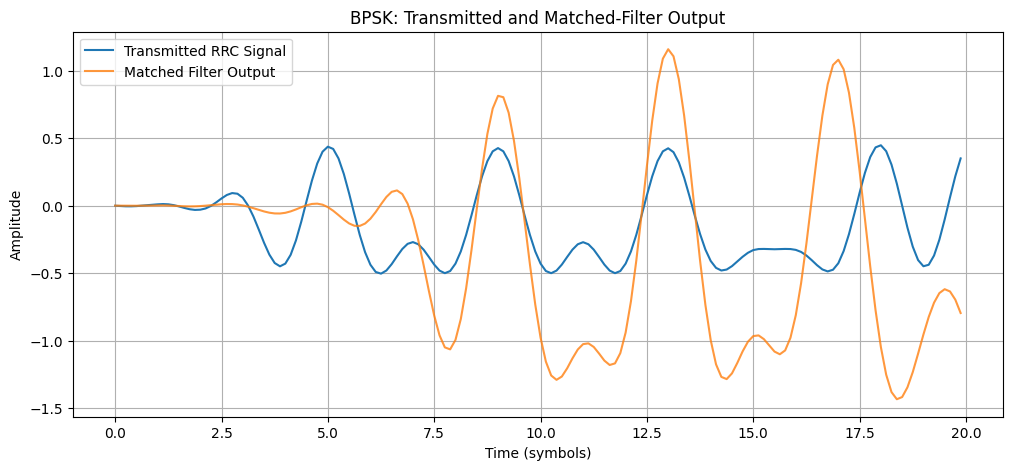

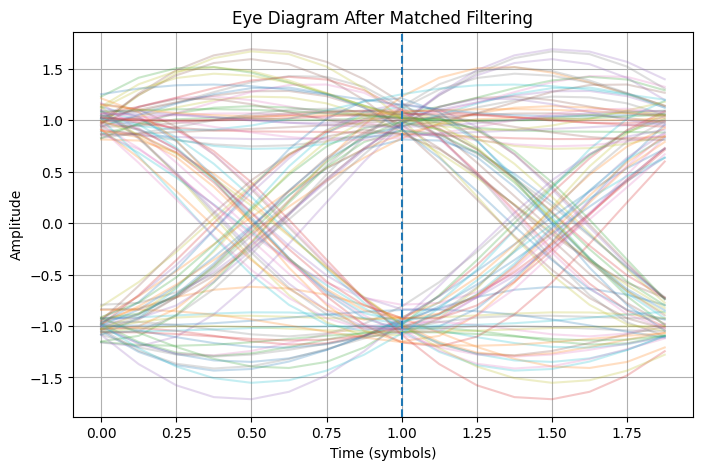

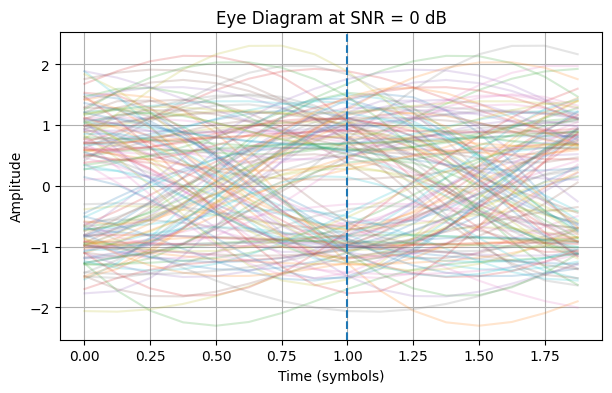

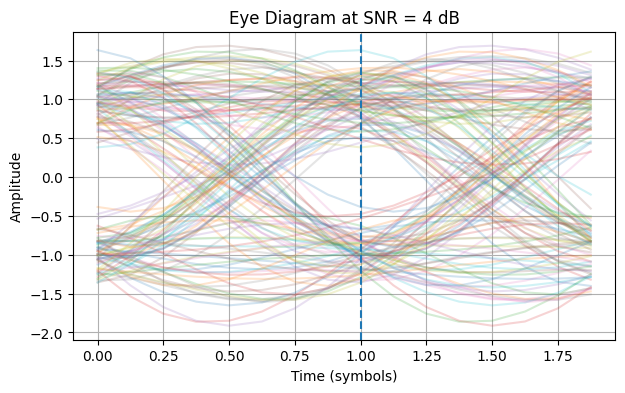

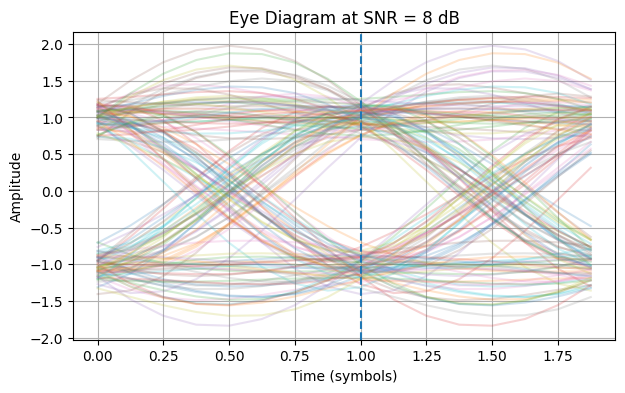

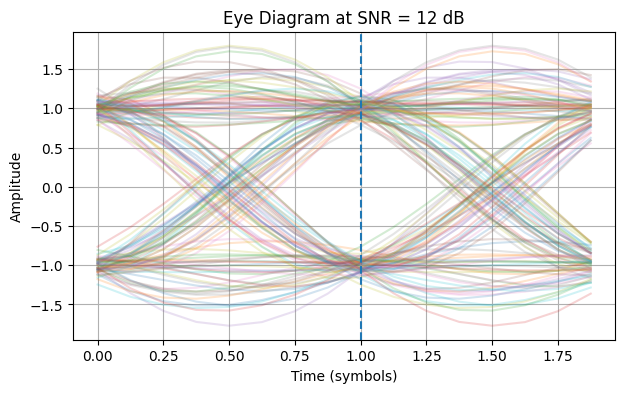

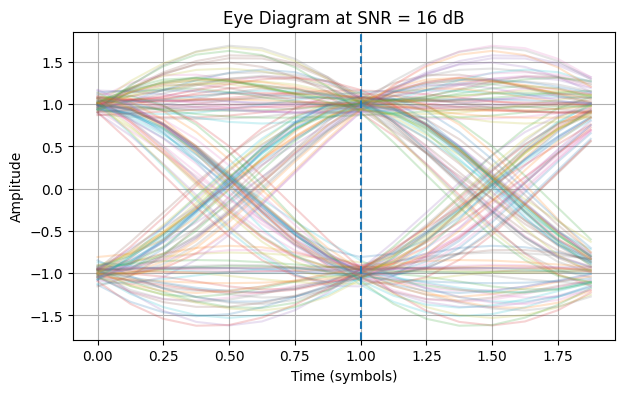

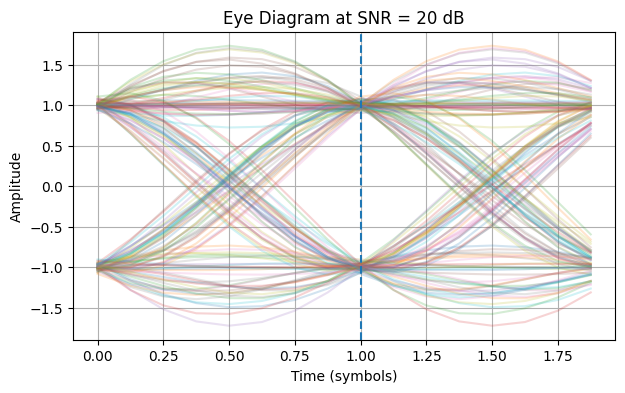

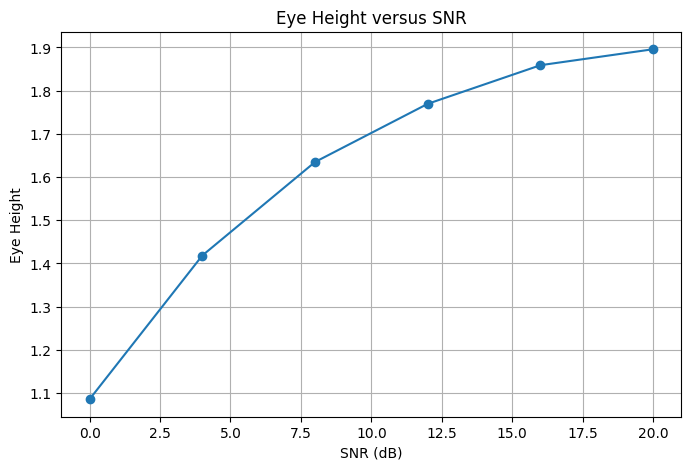

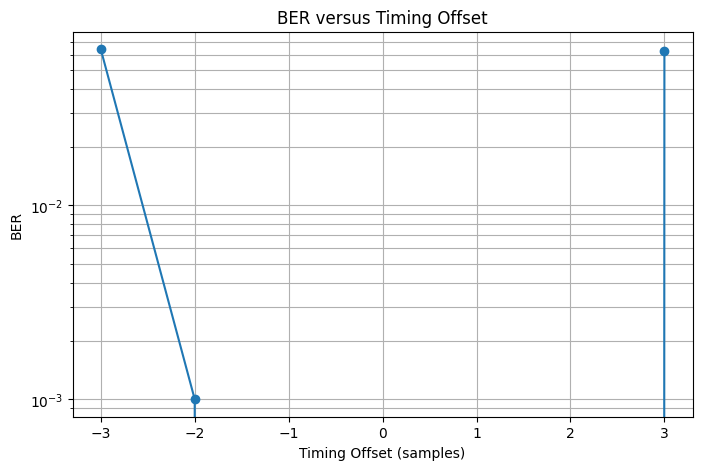


BER versus Timing Offset
--------------------------------
Offset = -3 samples    BER = 0.064000
Offset = -2 samples    BER = 0.001000
Offset = -1 samples    BER = 0.000000
Offset = +0 samples    BER = 0.000000
Offset = +1 samples    BER = 0.000000
Offset = +2 samples    BER = 0.000000
Offset = +3 samples    BER = 0.062750

----------------------------------------
OPTIMUM SAMPLING
----------------------------------------
Optimum timing offset = -1 samples
Corresponding BER = 0.0

----------------------------------------
MULTIPATH CHANNEL
----------------------------------------
Multipath delay = 5 samples
Channel taps = [1.  0.  0.  0.  0.  0.5]
Total delay with multipath = 69 samples


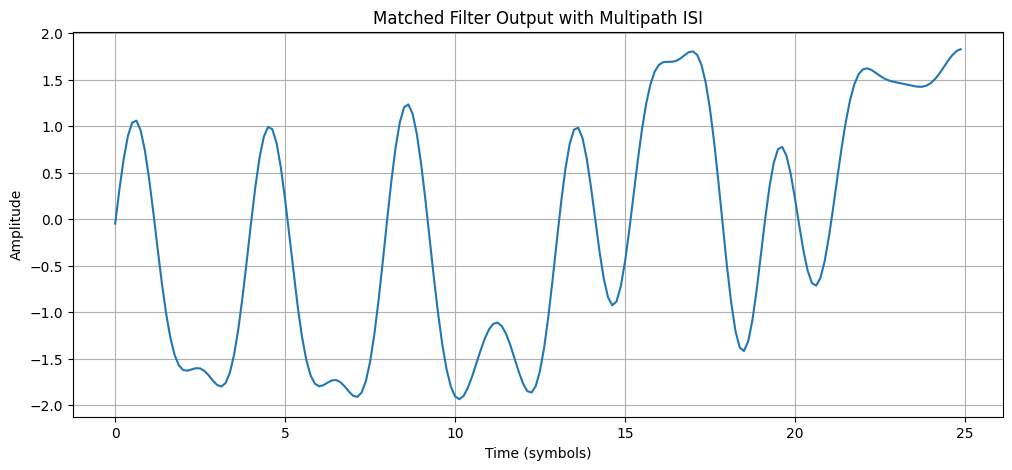

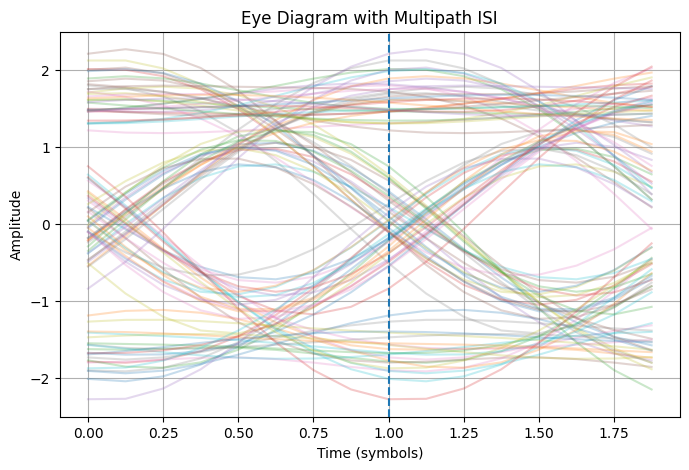


----------------------------------------
MULTIPATH BER
----------------------------------------
BER without multipath = 0.0
BER with multipath    = 0.13525

EXPERIMENT SUMMARY
RRC roll-off factor       : 0.35
Filter span               : 8 symbols
Samples per symbol        : 8
SNR                       : 10 dB
TX filter delay           : 32 samples
RX filter delay           : 32 samples
Total cascade delay       : 64 samples
BER without multipath     : 0.0
BER with multipath        : 0.13525
Optimum timing offset     : -1 samples


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 8
# MATCHED FILTERING, ISI AND EYE DIAGRAMS
# BPSK + RRC PULSE SHAPING + AWGN + MATCHED FILTER
# ============================================================

np.random.seed(42)

# ------------------------------------------------------------
# 1. PARAMETERS
# ------------------------------------------------------------

Nsym = 4000              # Number of BPSK symbols
sps = 8                  # Samples per symbol
rolloff = 0.35           # RRC roll-off factor
span = 8                 # RRC filter span in symbols

SNR_dB = 10              # Main SNR
symbol_rate = 1          # Normalized symbol rate

# Timing offsets in samples
timing_offsets = np.arange(-3, 4)

# SNR values for eye-height study
SNR_values = [0, 4, 8, 12, 16, 20]


# ============================================================
# 2. ROOT RAISED COSINE (RRC) FILTER
# ============================================================

def rrc_filter(beta, span, sps):
    """
    Generate a Root Raised Cosine (RRC) filter.

    beta : roll-off factor
    span : filter length in symbols
    sps  : samples per symbol
    """

    N = span * sps
    t = np.arange(-N/2, N/2 + 1) / sps

    h = np.zeros_like(t, dtype=float)

    for i, ti in enumerate(t):

        # t = 0
        if abs(ti) < 1e-12:

            h[i] = 1 + beta * (4/np.pi - 1)

        # t = ±T/(4*beta)
        elif beta != 0 and abs(abs(ti) - 1/(4*beta)) < 1e-12:

            h[i] = (beta / np.sqrt(2)) * (
                (1 + 2/np.pi) * np.sin(np.pi/(4*beta))
                +
                (1 - 2/np.pi) * np.cos(np.pi/(4*beta))
            )

        # General case
        else:

            numerator = (
                np.sin(np.pi * ti * (1 - beta))
                +
                4 * beta * ti * np.cos(np.pi * ti * (1 + beta))
            )

            denominator = (
                np.pi * ti * (1 - (4 * beta * ti)**2)
            )

            h[i] = numerator / denominator

    # Normalize energy
    h = h / np.sqrt(np.sum(h**2))

    return h


# Generate RRC filter
rrc = rrc_filter(rolloff, span, sps)

print("RRC filter length =", len(rrc))
print("Filter span       =", span, "symbols")
print("Samples/symbol    =", sps)


# ============================================================
# 3. GENERATE RANDOM BPSK SYMBOLS
# ============================================================

bits = np.random.randint(0, 2, Nsym)

# BPSK mapping:
# bit 0 -> -1
# bit 1 -> +1

symbols = 2 * bits - 1

print("\nFirst 20 bits:")
print(bits[:20])

print("\nFirst 20 BPSK symbols:")
print(symbols[:20])


# ============================================================
# 4. UPSAMPLING
# ============================================================

# Insert zeros between symbols

upsampled = np.zeros(Nsym * sps)
upsampled[::sps] = symbols


# ============================================================
# 5. TRANSMITTER RRC PULSE SHAPING
# ============================================================

tx_signal = np.convolve(upsampled, rrc, mode='full')


# ============================================================
# 6. ADD AWGN
# ============================================================

def add_awgn(signal, snr_db):

    signal_power = np.mean(signal**2)

    snr_linear = 10**(snr_db / 10)

    noise_power = signal_power / snr_linear

    noise = np.sqrt(noise_power) * np.random.randn(len(signal))

    return signal + noise


rx_channel = add_awgn(tx_signal, SNR_dB)


# ============================================================
# 7. MATCHED FILTER
# ============================================================

# Matched filter for a real symmetric RRC pulse
matched_output = np.convolve(rx_channel, rrc, mode='full')


# ============================================================
# 8. TOTAL CASCADE DELAY
# ============================================================

filter_delay = (len(rrc) - 1) // 2

total_delay = 2 * filter_delay

print("\n----------------------------------------")
print("DELAY VALIDATION")
print("----------------------------------------")

print("TX filter delay      =", filter_delay, "samples")
print("RX matched delay     =", filter_delay, "samples")
print("Total cascade delay  =", total_delay, "samples")
print("----------------------------------------")


# ============================================================
# 9. SAMPLE AFTER DELAY COMPENSATION
# ============================================================

# The first valid symbol occurs after total delay.
#
# Since the signal was originally upsampled with the first
# symbol at sample 0, the correct sampling points are:
#
# total_delay, total_delay+sps, total_delay+2*sps, ...

sample_indices = total_delay + np.arange(Nsym) * sps

# Keep only indices that exist
valid = sample_indices < len(matched_output)

sample_indices = sample_indices[valid]

detected_samples = matched_output[sample_indices.astype(int)]

original_symbols = symbols[:len(detected_samples)]


# ============================================================
# 10. DETECTION
# ============================================================

detected_bits = (detected_samples >= 0).astype(int)

original_bits = bits[:len(detected_bits)]

BER = np.mean(detected_bits != original_bits)

print("Number of detected symbols =", len(detected_samples))
print("BER at SNR =", SNR_dB, "dB =", BER)


# ============================================================
# 11. CHECK SYMBOL SAMPLES
# ============================================================

print("\nFirst 15 symbol decisions:")
print("----------------------------------------")

for i in range(15):

    print(
        f"Symbol {i+1:2d} : "
        f"Original = {original_symbols[i]:+d}, "
        f"Received = {detected_samples[i]:+.3f}, "
        f"Detected bit = {detected_bits[i]}"
    )


# ============================================================
# 12. TRANSMITTED AND MATCHED-FILTER OUTPUT
# ============================================================

plt.figure(figsize=(12, 5))

# Show first few symbols
display_samples = 20 * sps

time = np.arange(display_samples) / sps

plt.plot(
    time,
    tx_signal[:display_samples],
    label='Transmitted RRC Signal'
)

plt.plot(
    time,
    matched_output[:display_samples],
    label='Matched Filter Output',
    alpha=0.8
)

plt.xlabel("Time (symbols)")
plt.ylabel("Amplitude")
plt.title("BPSK: Transmitted and Matched-Filter Output")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 13. EYE DIAGRAM FUNCTION
# ============================================================

def plot_eye(signal, sps, title, n_traces=100):

    """
    Plot an eye diagram.

    Each trace contains two symbol periods.
    """

    samples_per_trace = 2 * sps

    # Starting positions for each eye trace
    starts = np.arange(
        0,
        min(
            len(signal) - samples_per_trace,
            n_traces * sps
        ),
        sps
    )

    plt.figure(figsize=(8, 5))

    t_eye = np.arange(samples_per_trace) / sps

    for start in starts:

        segment = signal[start:start + samples_per_trace]

        if len(segment) == samples_per_trace:
            plt.plot(t_eye, segment, alpha=0.25)

    plt.axvline(1, linestyle='--')

    plt.xlabel("Time (symbols)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)

    plt.show()


# ============================================================
# 14. EYE DIAGRAM AFTER MATCHED FILTER
# ============================================================

# Remove initial cascade delay before making eye diagram

eye_signal = matched_output[total_delay:]

plot_eye(
    eye_signal,
    sps,
    "Eye Diagram After Matched Filtering"
)


# ============================================================
# 15. EYE DIAGRAM FOR DIFFERENT SNR VALUES
# ============================================================

for snr in SNR_values:

    noisy_signal = add_awgn(tx_signal, snr)

    mf_signal = np.convolve(
        noisy_signal,
        rrc,
        mode='full'
    )

    # Remove total delay
    mf_eye = mf_signal[total_delay:]

    plt.figure(figsize=(7, 4))

    samples_per_trace = 2 * sps

    t_eye = np.arange(samples_per_trace) / sps

    n_traces = 150

    for k in range(n_traces):

        start = k * sps

        if start + samples_per_trace < len(mf_eye):

            segment = mf_eye[
                start:start + samples_per_trace
            ]

            plt.plot(
                t_eye,
                segment,
                alpha=0.2
            )

    plt.axvline(1, linestyle='--')

    plt.xlabel("Time (symbols)")
    plt.ylabel("Amplitude")

    plt.title(
        f"Eye Diagram at SNR = {snr} dB"
    )

    plt.grid(True)
    plt.show()


# ============================================================
# 16. EYE HEIGHT VERSUS SNR
# ============================================================

eye_heights = []

for snr in SNR_values:

    noisy_signal = add_awgn(tx_signal, snr)

    mf_signal = np.convolve(
        noisy_signal,
        rrc,
        mode='full'
    )

    # Remove cascade delay
    mf_signal = mf_signal[total_delay:]

    # Sample near optimum instant
    sample_positions = np.arange(
        0,
        min(Nsym, len(mf_signal)//sps)
    ) * sps

    samples = mf_signal[
        sample_positions.astype(int)
    ]

    # Estimate eye opening using positive and negative levels
    positive = samples[samples > 0]
    negative = samples[samples < 0]

    if len(positive) > 0 and len(negative) > 0:

        upper = np.percentile(positive, 10)
        lower = np.percentile(negative, 90)

        eye_height = upper - lower

    else:

        eye_height = 0

    eye_heights.append(eye_height)


# Plot eye height
plt.figure(figsize=(8, 5))

plt.plot(
    SNR_values,
    eye_heights,
    marker='o'
)

plt.xlabel("SNR (dB)")
plt.ylabel("Eye Height")
plt.title("Eye Height versus SNR")
plt.grid(True)
plt.show()


# ============================================================
# 17. BER VERSUS TIMING OFFSET
# ============================================================

timing_BER = []

# Use the already generated matched filter output
for offset in timing_offsets:

    # Sampling position = optimum instant + timing offset
    indices = (
        total_delay
        + np.arange(Nsym) * sps
        + offset
    )

    valid = (
        (indices >= 0)
        &
        (indices < len(matched_output))
    )

    indices = indices[valid].astype(int)

    received = matched_output[indices]

    transmitted = symbols[:len(received)]

    detected = np.where(
        received >= 0,
        1,
        -1
    )

    ber = np.mean(
        detected != transmitted
    )

    timing_BER.append(ber)


# Plot BER vs timing offset

plt.figure(figsize=(8, 5))

plt.semilogy(
    timing_offsets,
    timing_BER,
    marker='o'
)

plt.xlabel("Timing Offset (samples)")
plt.ylabel("BER")
plt.title("BER versus Timing Offset")
plt.grid(True, which='both')

plt.show()


# ============================================================
# 18. PRINT TIMING OFFSET RESULTS
# ============================================================

print("\nBER versus Timing Offset")
print("--------------------------------")

for offset, ber in zip(
    timing_offsets,
    timing_BER
):

    print(
        f"Offset = {offset:+2d} samples"
        f"    BER = {ber:.6f}"
    )


# ============================================================
# 19. FIND OPTIMUM SAMPLING INSTANT
# ============================================================

best_index = np.argmin(timing_BER)

best_offset = timing_offsets[best_index]

print("\n----------------------------------------")
print("OPTIMUM SAMPLING")
print("----------------------------------------")

print(
    "Optimum timing offset =",
    best_offset,
    "samples"
)

print(
    "Corresponding BER =",
    timing_BER[best_index]
)


# ============================================================
# 20. MULTIPATH CHANNEL
# ============================================================

# Multipath channel:
#
# h[n] = 1 + 0.5 delayed by 0.7 symbol
#
# This creates ISI.

multipath_delay = int(0.7 * sps)

channel = np.zeros(
    multipath_delay + 1
)

channel[0] = 1
channel[multipath_delay] = 0.5


print("\n----------------------------------------")
print("MULTIPATH CHANNEL")
print("----------------------------------------")

print(
    "Multipath delay =",
    multipath_delay,
    "samples"
)

print(
    "Channel taps =",
    channel
)


# ============================================================
# 21. TRANSMISSION THROUGH MULTIPATH CHANNEL
# ============================================================

multipath_signal = np.convolve(
    tx_signal,
    channel,
    mode='full'
)

multipath_signal = add_awgn(
    multipath_signal,
    SNR_dB
)


# ============================================================
# 22. MATCHED FILTER AFTER MULTIPATH
# ============================================================

multipath_mf = np.convolve(
    multipath_signal,
    rrc,
    mode='full'
)


# Total delay:
#
# TX RRC delay
# + multipath channel delay
# + RX RRC delay

multipath_total_delay = (
    total_delay + multipath_delay
)

print(
    "Total delay with multipath =",
    multipath_total_delay,
    "samples"
)


# ============================================================
# 23. MULTIPATH OUTPUT PLOT
# ============================================================

plt.figure(figsize=(12, 5))

display_samples = 25 * sps

t = np.arange(display_samples) / sps

plt.plot(
    t,
    multipath_mf[
        multipath_total_delay:
        multipath_total_delay + display_samples
    ]
)

plt.xlabel("Time (symbols)")
plt.ylabel("Amplitude")

plt.title(
    "Matched Filter Output with Multipath ISI"
)

plt.grid(True)
plt.show()


# ============================================================
# 24. MULTIPATH EYE DIAGRAM
# ============================================================

multipath_eye = multipath_mf[
    multipath_total_delay:
]

plot_eye(
    multipath_eye,
    sps,
    "Eye Diagram with Multipath ISI"
)


# ============================================================
# 25. BER WITH MULTIPATH
# ============================================================

indices = (
    multipath_total_delay
    + np.arange(Nsym) * sps
)

valid = indices < len(multipath_mf)

indices = indices[valid].astype(int)

received = multipath_mf[indices]

transmitted = symbols[:len(received)]

detected = np.where(
    received >= 0,
    1,
    -1
)

BER_multipath = np.mean(
    detected != transmitted
)

print("\n----------------------------------------")
print("MULTIPATH BER")
print("----------------------------------------")

print(
    "BER without multipath =",
    BER
)

print(
    "BER with multipath    =",
    BER_multipath
)


# ============================================================
# 26. SUMMARY
# ============================================================

print("\n========================================")
print("EXPERIMENT SUMMARY")
print("========================================")

print(
    "RRC roll-off factor       :",
    rolloff
)

print(
    "Filter span               :",
    span,
    "symbols"
)

print(
    "Samples per symbol        :",
    sps
)

print(
    "SNR                       :",
    SNR_dB,
    "dB"
)

print(
    "TX filter delay           :",
    filter_delay,
    "samples"
)

print(
    "RX filter delay           :",
    filter_delay,
    "samples"
)

print(
    "Total cascade delay       :",
    total_delay,
    "samples"
)

print(
    "BER without multipath     :",
    BER
)

print(
    "BER with multipath        :",
    BER_multipath
)

print(
    "Optimum timing offset     :",
    best_offset,
    "samples"
)

print("========================================")